# Semana 10: Clustering de Alojamientos

Aplicamos aprendizaje no supervisado para agrupar los alojamientos en segmentos según su precio, calidad y posición en el mercado. Usamos K-Means y DBSCAN sobre los datos ya limpios (processed_data) que dejamos en el EDA.

El objetivo es encontrar grupos de alojamientos con características parecidas, útiles para decidir dónde y en qué tipo conviene invertir.

## Conexión y carga de datos

In [1]:
import os
from dotenv import load_dotenv
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

spark = SparkSession.builder \
    .appName("Clustering_Alojamientos") \
    .config("spark.mongodb.read.connection.uri", MONGO_URI) \
    .config("spark.mongodb.write.connection.uri", MONGO_URI) \
    .getOrCreate()

df = spark.read.format("mongodb") \
    .option("database", "proyecto_bigdata") \
    .option("collection", "processed_data") \
    .load()

print("Registros cargados:", df.count())
df.printSchema()

Registros cargados: 3584
root
 |-- _id: string (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- desvio_precio_ciudad: double (nullable = true)
 |-- desvio_precio_tipo: double (nullable = true)
 |-- estrellas: double (nullable = true)
 |-- nombre_hotel: string (nullable = true)
 |-- plataforma: string (nullable = true)
 |-- precio_clp: double (nullable = true)
 |-- puntuacion: double (nullable = true)
 |-- tipo_alojamiento: string (nullable = true)
 |-- zona_geografica: string (nullable = true)



## Revisar correlación entre las columnas

Antes de elegir las columnas definitivas, revisamos si alguna se repite con otra. Si dos columnas están muy correlacionadas (dicen casi lo mismo), conviene dejar solo una para que el clustering no le dé peso doble al precio.

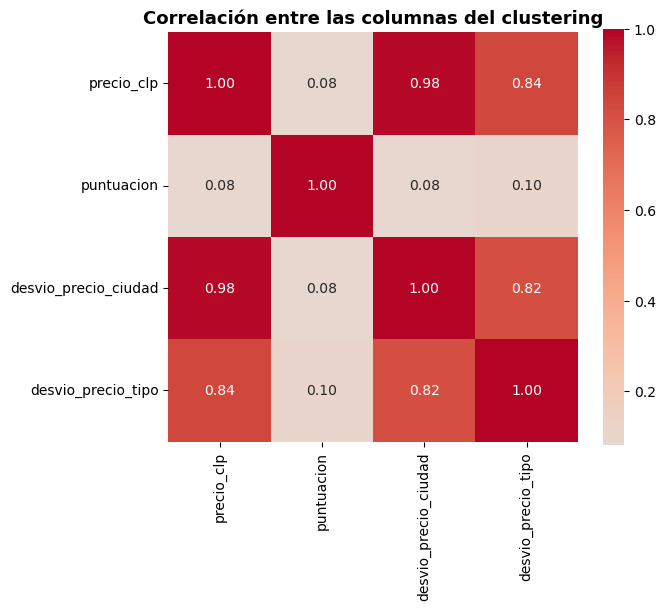

                      precio_clp  puntuacion  desvio_precio_ciudad  \
precio_clp              1.000000    0.080951              0.982711   
puntuacion              0.080951    1.000000              0.080633   
desvio_precio_ciudad    0.982711    0.080633              1.000000   
desvio_precio_tipo      0.835148    0.099408              0.817438   

                      desvio_precio_tipo  
precio_clp                      0.835148  
puntuacion                      0.099408  
desvio_precio_ciudad            0.817438  
desvio_precio_tipo              1.000000  


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

columnas = ["precio_clp", "puntuacion", "desvio_precio_ciudad", "desvio_precio_tipo"]
pdf_corr = df.select(columnas).toPandas()

corr = pdf_corr.corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True)
plt.title("Correlación entre las columnas del clustering", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print(corr)

**Qué muestra:** las tres columnas de precio (precio_clp, desvio_precio_ciudad, desvio_precio_tipo) están muy correlacionadas entre sí (0.82 a 0.98), o sea dicen casi lo mismo. Meterlas las tres haría que el precio pese de más. En cambio, `puntuacion` es independiente de todas (correlación 0.08-0.10), así que aporta información distinta.

**Decisión:** para el clustering usamos `precio_clp` y `puntuacion`. Son dos ejes claros (cuánto cuesta y qué tan bien evaluado está), no se repiten entre sí y son fáciles de interpretar. Las columnas de desvío se quedan en los datos pero no entran al modelo, porque ya están representadas por el precio.

## Preparación: vectorizar, escalar y PCA

In [3]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA

features_cols = ["precio_clp", "puntuacion"]

df_model = df.dropna(subset=features_cols)

assembler = VectorAssembler(inputCols=features_cols, outputCol="features")
df_vector = assembler.transform(df_model)

scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

pca = PCA(k=2, inputCol="scaledFeatures", outputCol="pcaFeatures")
pca_model = pca.fit(df_scaled)
df_pca = pca_model.transform(df_scaled)

print("Datos vectorizados, escalados y reducidos con PCA")
print("Varianza explicada por los 2 componentes:", pca_model.explainedVariance.toArray())

Datos vectorizados, escalados y reducidos con PCA
Varianza explicada por los 2 componentes: [0.54047573 0.45952427]


## Método del codo: ¿cuántos clusters?

Probamos distintos valores de K (de 2 a 10) y medimos la inercia (qué tan compactos quedan los grupos). El "codo" del gráfico marca el K donde agregar más clusters ya no mejora mucho.

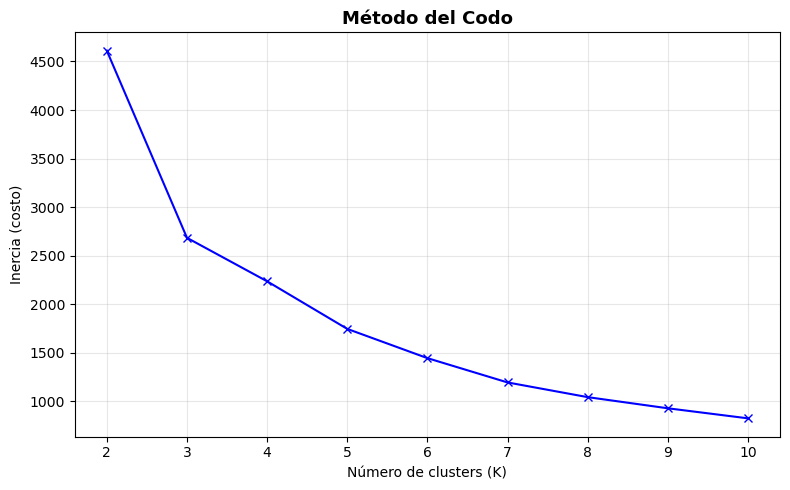

In [4]:
from pyspark.ml.clustering import KMeans

cost = []
for k in range(2, 11):
    kmeans = KMeans(featuresCol="scaledFeatures", k=k, seed=42)
    model = kmeans.fit(df_scaled)
    cost.append(model.summary.trainingCost)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), cost, "bx-")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia (costo)")
plt.title("Método del Codo", fontsize=13, fontweight="bold")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Miramos el gráfico y elegimos el K donde se forma el "codo" (donde la curva deja de bajar fuerte). Ajusta `k_optimo` abajo según lo que muestre.

## K-Means final

In [5]:
k_optimo = 3

kmeans_final = KMeans(featuresCol="scaledFeatures", k=k_optimo, seed=42)
model_final = kmeans_final.fit(df_scaled)
df_clusters = model_final.transform(df_scaled)

print(f"K-Means con k={k_optimo}")
df_clusters.groupBy("prediction").count().orderBy("prediction").show()

K-Means con k=3
+----------+-----+
|prediction|count|
+----------+-----+
|         0| 1534|
|         1| 1217|
|         2|  833|
+----------+-----+



### Guardar los datos con su cluster
Guardamos los alojamientos junto con el grupo (cluster) que les asignó el K-Means en una colección nueva de MongoDB. Esto lo usará el notebook de la Semana 12 (aprendizaje supervisado) para entrenar un modelo que aprenda a predecir el grupo.

In [6]:
df_guardar = df_clusters.select(
    "nombre_hotel", "ciudad", "tipo_alojamiento", "precio_clp",
    "puntuacion", "estrellas", "prediction")

df_guardar.write.format("mongodb") \
    .option("database", "proyecto_bigdata") \
    .option("collection", "datos_clusters") \
    .mode("overwrite") \
    .save()
print("Datos con cluster guardados en 'datos_clusters'. Registros:", df_guardar.count())

Datos con cluster guardados en 'datos_clusters'. Registros: 3584


### Caracterizar cada cluster
Vemos el promedio de cada variable por cluster, para entender qué agrupa cada uno y poder ponerle un nombre con sentido (económicos, premium, etc.).

In [7]:
from pyspark.sql.functions import avg, count, round as spark_round

resumen = df_clusters.groupBy("prediction").agg(
    count("*").alias("cantidad"),
    spark_round(avg("precio_clp")).alias("precio_prom"),
    spark_round(avg("puntuacion"),2).alias("puntuacion_prom")
).orderBy("prediction")
resumen.show()

+----------+--------+-----------+---------------+
|prediction|cantidad|precio_prom|puntuacion_prom|
+----------+--------+-----------+---------------+
|         0|    1534|    68069.0|           8.98|
|         1|    1217|    67048.0|           7.56|
|         2|     833|   167145.0|           8.52|
+----------+--------+-----------+---------------+



## Visualización de los clusters (espacio PCA)

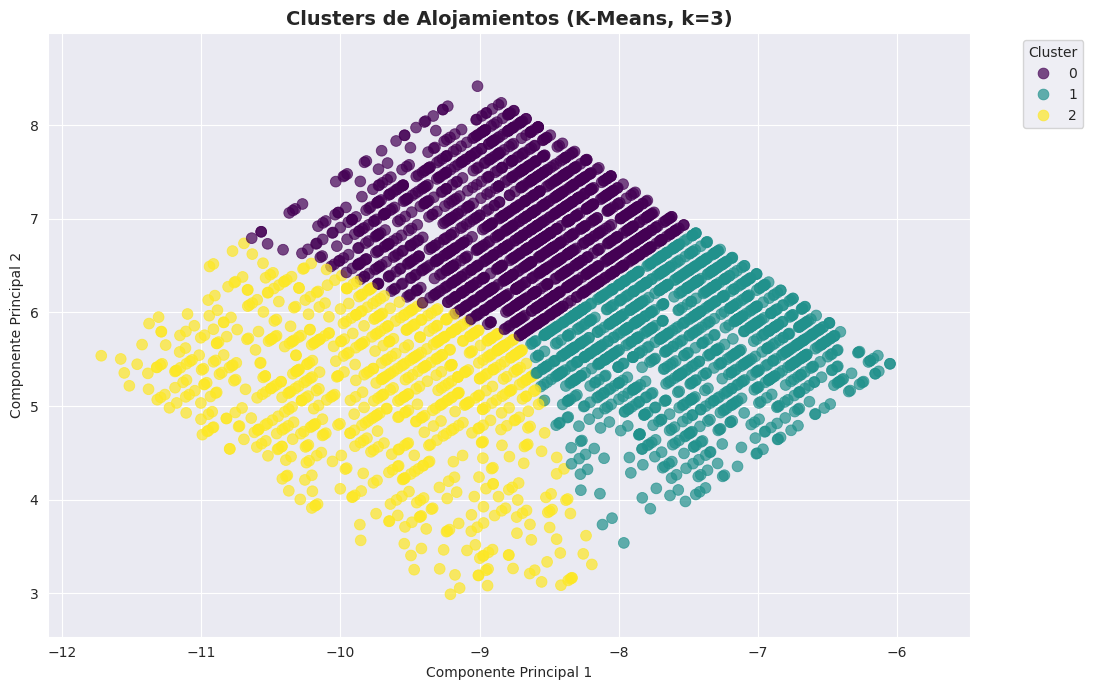

In [8]:
import numpy as np

df_viz = model_final.transform(df_pca)
pdf_visual = df_viz.select("pcaFeatures", "prediction").toPandas()
pdf_visual[["PC1","PC2"]] = pd.DataFrame(
    pdf_visual["pcaFeatures"].apply(lambda x: x.toArray()).tolist())

pc1_min, pc1_max = np.percentile(pdf_visual["PC1"], [1, 99])
pc2_min, pc2_max = np.percentile(pdf_visual["PC2"], [1, 99])

plt.figure(figsize=(11,7))
sns.set_style("darkgrid")
sns.scatterplot(data=pdf_visual, x="PC1", y="PC2", hue="prediction",
                palette="viridis", s=60, alpha=0.7, edgecolor=None)
plt.xlim(pc1_min-1, pc1_max+1); plt.ylim(pc2_min-1, pc2_max+1)
plt.title(f"Clusters de Alojamientos (K-Means, k={k_optimo})", fontsize=14, fontweight="bold")
plt.xlabel("Componente Principal 1"); plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout(); plt.show()

## DBSCAN (comparación)

A diferencia de K-Means, DBSCAN no necesita que le digamos cuántos grupos hay y detecta solo los outliers (alojamientos que no se parecen a nada, marcados como -1). Como PySpark no trae DBSCAN nativo, lo aplicamos con scikit-learn sobre los datos ya reducidos por PCA.

In [9]:
from sklearn.cluster import DBSCAN

pdf_dbscan = df_pca.select("pcaFeatures").toPandas()
X = np.array(pdf_dbscan["pcaFeatures"].apply(lambda x: x.toArray()).tolist())

dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters_db = dbscan.fit_predict(X)
pdf_dbscan["cluster_dbscan"] = clusters_db

n_clusters = len(set(clusters_db)) - (1 if -1 in clusters_db else 0)
n_ruido = list(clusters_db).count(-1)
print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido (outliers): {n_ruido}")

Clusters encontrados: 1
Puntos de ruido (outliers): 0


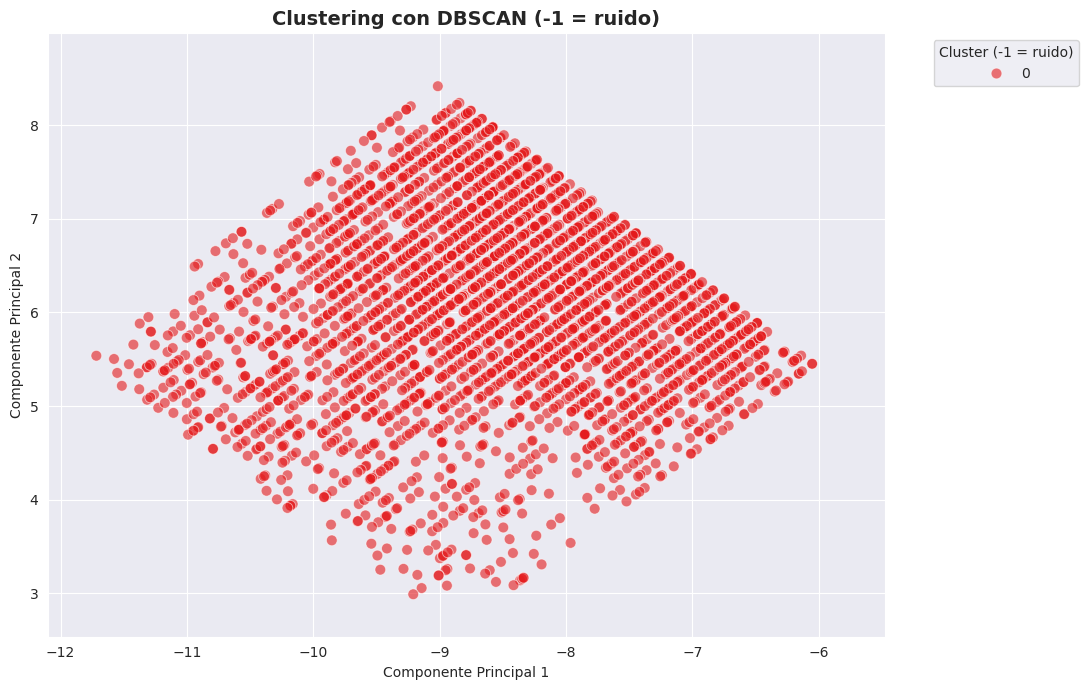

In [10]:
pdf_dbscan[["PC1","PC2"]] = pd.DataFrame(X, columns=["PC1","PC2"])
pc1_min, pc1_max = np.percentile(pdf_dbscan["PC1"], [1, 99])
pc2_min, pc2_max = np.percentile(pdf_dbscan["PC2"], [1, 99])

plt.figure(figsize=(11,7))
sns.set_style("darkgrid")
sns.scatterplot(data=pdf_dbscan, x="PC1", y="PC2", hue="cluster_dbscan",
                palette="Set1", s=60, alpha=0.6)
plt.xlim(pc1_min-1, pc1_max+1); plt.ylim(pc2_min-1, pc2_max+1)
plt.title("Clustering con DBSCAN (-1 = ruido)", fontsize=14, fontweight="bold")
plt.xlabel("Componente Principal 1"); plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster (-1 = ruido)", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout(); plt.show()

**Qué muestra el DBSCAN:** no encontró grupos separados (quedó todo en un solo grupo) ni marcó outliers. Esto no es un fallo, sino un resultado que dice algo del mercado: los alojamientos forman un **bloque continuo**, donde el precio y la puntuación varían de forma gradual, sin huecos que separen grupos naturales. DBSCAN necesita zonas vacías entre grupos para distinguirlos, y aquí no las hay.

Por eso **K-Means fue el método adecuado** para este caso: permite definir cuántos segmentos queremos (los 3 que elegimos con el método del codo) aunque los datos sean un continuo. La comparación entre ambos métodos confirma que la segmentación en 3 grupos es una decisión nuestra basada en el negocio, no grupos que aparezcan aislados de forma natural.

## ¿Qué tipo de alojamiento hay en cada cluster?

El clustering agrupó por precio y calidad, pero para decidir dónde invertir necesitamos saber qué tipo de alojamiento compone cada grupo. Cruzamos los clusters con el tipo (lo principal del proyecto) para ver, por ejemplo, si el grupo barato y bien evaluado son hoteles, hostales o departamentos.

+----------+----------------+-----+
|prediction|tipo_alojamiento|count|
+----------+----------------+-----+
|0         |hotel           |759  |
|0         |hostal          |407  |
|0         |apartamento     |198  |
|0         |casa/cabana     |170  |
|1         |hotel           |505  |
|1         |hostal          |358  |
|1         |apartamento     |183  |
|1         |casa/cabana     |171  |
|2         |hotel           |701  |
|2         |hostal          |53   |
|2         |casa/cabana     |44   |
|2         |apartamento     |35   |
+----------+----------------+-----+



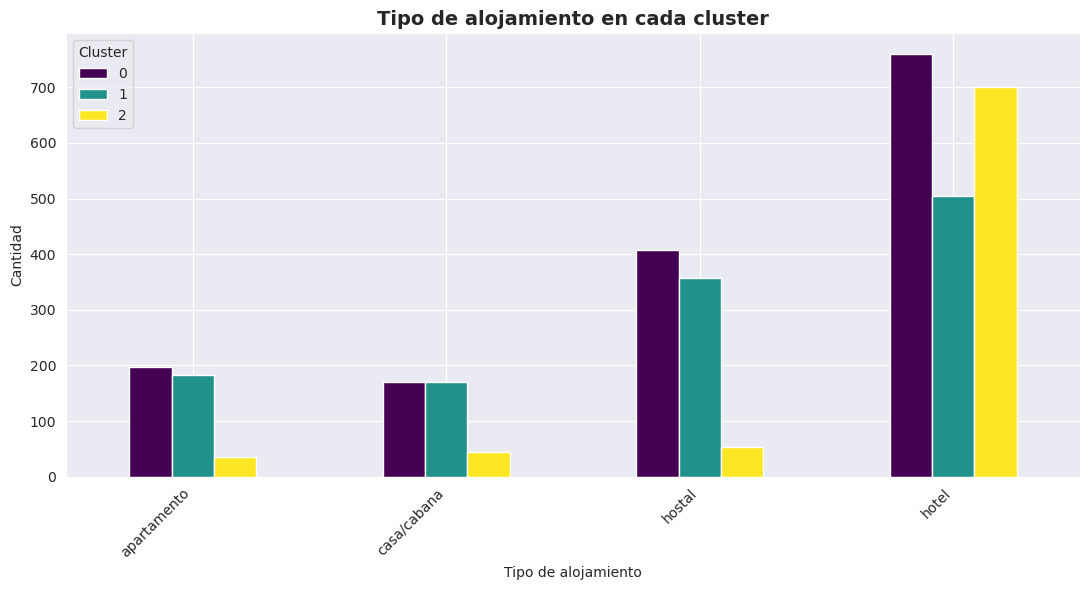

In [11]:
tabla_tipo = df_clusters.groupBy("prediction", "tipo_alojamiento").count() \
    .orderBy("prediction", col("count").desc())
tabla_tipo.show(50, truncate=False)

pdf_tipo = tabla_tipo.toPandas()
pivot = pdf_tipo.pivot(index="tipo_alojamiento", columns="prediction", values="count").fillna(0)
pivot.plot(kind="bar", figsize=(11,6), colormap="viridis")
plt.title("Tipo de alojamiento en cada cluster", fontsize=14, fontweight="bold")
plt.xlabel("Tipo de alojamiento"); plt.ylabel("Cantidad")
plt.legend(title="Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

## ¿En qué ciudades está cada cluster?

Para responder dónde conviene invertir, vemos en qué ciudades se concentra cada grupo. Lo más útil es mirar el cluster de oportunidad (precio bajo y buena puntuación): si se concentra en ciertas ciudades, esas son las que ofrecen mejor relación precio-calidad para entrar al mercado.

In [12]:
tabla_ciudad = df_clusters.groupBy("prediction", "ciudad").count() \
    .orderBy("prediction", col("count").desc())

import pandas as pd
pdf_ciudad = tabla_ciudad.toPandas()

for c in sorted(pdf_ciudad["prediction"].unique()):
    print(f"\n=== Cluster {c}: top 8 ciudades ===")
    top = pdf_ciudad[pdf_ciudad["prediction"]==c].nlargest(8, "count")
    print(top[["ciudad","count"]].to_string(index=False))


=== Cluster 0: top 8 ciudades ===
      ciudad  count
  Valparaiso    106
    Valdivia     89
     Iquique     89
   La Serena     88
     Chillan     88
Punta Arenas     85
Puerto Varas     83
Puerto Montt     83

=== Cluster 1: top 8 ciudades ===
      ciudad  count
 Antofagasta     82
       Arica     77
Puerto Montt     72
    Santiago     69
     Copiapo     65
      Calama     65
    Rancagua     65
       Talca     64

=== Cluster 2: top 8 ciudades ===
        ciudad  count
      Santiago     87
    Valparaiso     57
    Concepcion     56
  Vina del Mar     54
   Antofagasta     46
Puerto Natales     44
        Calama     43
      Valdivia     43


## Conclusiones

Resumen de lo que muestran los clusters: qué segmentos de alojamientos se identificaron y qué significan para la decisión de inversión. (Completar según los resultados al correr el notebook.)